<a href="https://colab.research.google.com/github/mezlet/PPI-Inhibitors-main/blob/main/Complete_PPI_Inhibitors_Pipeline_End_To_End_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Complete PPI Inhibitors Prediction Pipeline
## Graph Neural Network for Predicting Small-Molecule Inhibition of Protein Complexes

**Set Runtime → Change Runtime Type to GPU**

This notebook includes:
- Training on primary dataset (714 inhibitors, 23 complexes)
- Leave-One-Complex-Out (LOCO) cross-validation
- External validation on 2dyh (MDM2-p53) dataset
- External validation on 6m0j (SARS-CoV-2 Spike/ACE2) dataset
- Performance metrics and visualizations

## 1. Setup and Installation

In [1]:
# Install dependencies
!pip install --upgrade pip setuptools wheel
!pip install rdkit biopython==1.81 torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 torch-geometric==2.5.3 tqdm==4.66.2 pandas==2.1.4 numpy==1.26.4 scikit-learn==1.3.2 matplotlib==3.8.3 seaborn==0.13.2 networkx==3.2.1 gdown


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 83.4 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 15.2 MB/s  0:00:30
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 121.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 143.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 115.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 108.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 97.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 17.5 MB/s  0:00:15
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 152.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 132.3 MB/s  0:00:00
   ━━━━━━━━━

In [1]:
# Clone repository
!rm -rf PPI-Inhibitors
!git clone https://github.com/adibayaseen/PPI-Inhibitors.git

Cloning into 'PPI-Inhibitors'...
remote: Enumerating objects: 1341, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 1341 (delta 76), reused 34 (delta 34), pack-reused 1256 (from 3)
Receiving objects: 100% (1341/1341), 2.59 GiB | 21.95 MiB/s, done.
Resolving deltas: 100% (401/401), done.
Updating files: 100% (605/605), done.


In [2]:
%cd PPI-Inhibitors
!mkdir -p Data

%cd Data
!wget -q https://github.com/adibayaseen/PPI-Inhibitors/raw/01ad4975fb9133825b1bf9e71b64fcdaaa5e4d8b/Data/2p2iComplexPairs.txt
!wget -q https://github.com/adibayaseen/PPI-Inhibitors/raw/01ad4975fb9133825b1bf9e71b64fcdaaa5e4d8b/Data/2p2iInhibitorsSMILES.txt
!wget -q https://github.com/adibayaseen/PPI-Inhibitors/raw/2d6bd03422602ec19147870c487e64018b52660f/Data/WriteAllexamplesRandomBindersIdsAll_24JAN_Binary.txt
!wget -q https://github.com/adibayaseen/PPI-Inhibitors/raw/b1e45884f61f792399abad2e4492f48083ab1093/Data/BindersWithComplexname.csv
%cd ..

/content/PPI-Inhibitors
/content/PPI-Inhibitors/Data
/content/PPI-Inhibitors


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd '/content/drive/MyDrive'

# Make folders
!mkdir -p GNN-PPI-Inhibitor
!gdown --id 1goeDiPZSKT1Xx3j00eNG9xlqYkLLv1gW -O GNN-PPI-Inhibitor/ProteinData_dict.pickle
!gdown --id 1GOYEKLQCoGea9QQ72kujy0rdJKbUSYAE -O GNN-PPI-Inhibitor/DBD5_ProteinData_dict.pickle

/content/drive/MyDrive
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1goeDiPZSKT1Xx3j00eNG9xlqYkLLv1gW
To: /content/drive/MyDrive/GNN-PPI-Inhibitor/ProteinData_dict.pickle
100% 34.6M/34.6M [00:00<00:00, 106MB/s] 
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1GOYEKLQCoGea9QQ72kujy0rdJKbUSYAE
From (redirected): https://drive.google.com/uc?id=1GOYEKLQCoGea9QQ72kujy0rdJKbUSYAE&confirm=t&uuid=586ab6ce-c555-4162-9bce-a0625596410d
To: /content/drive/MyDrive/GNN-PPI-Inhibitor/DBD5_ProteinData_dict.pickle
100% 336M/336M [00:04<00:00, 73.

## 2. Import Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.autograd import Variable

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm

from Bio.PDB import PDBParser, NeighborSearch
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, auc
)
from rdkit import Chem
from rdkit.Chem import AllChem

# Check GPU availability
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda:0" if USE_CUDA else "cpu")
print(f"Using device: {device}")
if USE_CUDA:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda:0
GPU: Tesla T4


## 3. Utility Functions

In [4]:
def cuda(v):
    if USE_CUDA:
        return v.cuda()
    return v

def toTensor(v, dtype=torch.float, requires_grad=False):
    return cuda(Variable(torch.tensor(v)).type(dtype).requires_grad_(requires_grad))

def toNumpy(v):
    if USE_CUDA:
        return v.detach().cpu().numpy()
    return v.detach().numpy()

## 4. PDB Processing Functions

In [5]:
def atom1(structure):
    """One-hot encode atom types (13 types)"""
    atomslist = np.array(sorted(['C', 'CA', 'CB', 'CG', 'CH2', 'N', 'NH2',
                                  'OG', 'OH', 'O1', 'O2', 'SE', '1'])).reshape(-1, 1)
    enc = OneHotEncoder(handle_unknown='ignore')
    enc.fit(atomslist)

    atom_list = []
    for atom in structure.get_atoms():
        if atom.get_name() in atomslist:
            atom_list.append(atom.get_name())
        else:
            atom_list.append("1")

    atoms_onehot = enc.transform(np.array(atom_list).reshape(-1, 1)).toarray()
    return atoms_onehot

def res1(structure):
    """One-hot encode residue types (21 types)"""
    residuelist = np.array(sorted(['ALA', 'ARG', 'ASN', 'ASP', 'GLN', 'GLU',
                                    'GLY', 'ILE', 'LEU', 'LYS', 'MET', 'PHE',
                                    'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL',
                                    'CYS', 'HIS', '1'])).reshape(-1, 1)
    encr = OneHotEncoder(handle_unknown='ignore')
    encr.fit(residuelist)

    residue_list = []
    for atom in structure.get_atoms():
        if atom.get_parent().get_resname() in residuelist:
            residue_list.append(atom.get_parent().get_resname())
        else:
            residue_list.append("1")

    res_onehot = encr.transform(np.array(residue_list).reshape(-1, 1)).toarray()
    return res_onehot

def neigh1(structure, cutoff=6.0, max_neighbors=10):
    """Calculate neighbors for each atom (same residue and different residue)"""
    atom_list = np.array([atom for atom in structure.get_atoms()])
    p4 = NeighborSearch(atom_list)
    neighbour_list = p4.search_all(cutoff, level="A")
    neighbour_list = np.array(neighbour_list)

    dist = np.array([nl[0] - nl[1] for nl in neighbour_list])
    place = np.argsort(dist)
    sorted_neighbour_list = neighbour_list[place]

    source_vertex_list = np.array(sorted_neighbour_list[:, 0])
    neighbour_vertex_list = np.array(sorted_neighbour_list[:, 1])

    old_atom_number = [atom.get_serial_number() for atom in atom_list]
    old_residue_number = [atom.get_parent().get_id()[1] for atom in atom_list]
    old_atom_number = np.array(old_atom_number)
    old_residue_number = np.array(old_residue_number)

    total_atoms = len(atom_list)
    neigh_same_res = np.array([[-1] * max_neighbors for _ in range(total_atoms)])
    neigh_diff_res = np.array([[-1] * max_neighbors for _ in range(total_atoms)])
    same_flag = [0] * total_atoms
    diff_flag = [0] * total_atoms

    for i in range(len(source_vertex_list)):
        source_atom_id = source_vertex_list[i].get_serial_number()
        neigh_atom_id = neighbour_vertex_list[i].get_serial_number()
        source_atom_res = source_vertex_list[i].get_parent().get_id()[1]
        neigh_atom_res = neighbour_vertex_list[i].get_parent().get_id()[1]

        temp_index1 = np.where(source_atom_id == old_atom_number)[0]
        temp_index2 = np.where(neigh_atom_id == old_atom_number)[0]

        source_index = None
        neigh_index = None

        for i1 in temp_index1:
            if old_residue_number[i1] == source_atom_res:
                source_index = i1
                break

        for i1 in temp_index2:
            if old_residue_number[i1] == neigh_atom_res:
                neigh_index = i1
                break

        if source_index is None or neigh_index is None:
            continue

        if source_atom_res == neigh_atom_res:
            if same_flag[source_index] < max_neighbors:
                neigh_same_res[source_index][same_flag[source_index]] = neigh_index
                same_flag[source_index] += 1
            if same_flag[neigh_index] < max_neighbors:
                neigh_same_res[neigh_index][same_flag[neigh_index]] = source_index
                same_flag[neigh_index] += 1
        else:
            if diff_flag[source_index] < max_neighbors:
                neigh_diff_res[source_index][diff_flag[source_index]] = neigh_index
                diff_flag[source_index] += 1
            if diff_flag[neigh_index] < max_neighbors:
                neigh_diff_res[neigh_index][diff_flag[neigh_index]] = source_index
                diff_flag[neigh_index] += 1

    return neigh_same_res, neigh_diff_res

def process_pdb_to_graph(pdb_path):
    """Convert PDB file to graph representation"""
    parser = PDBParser(QUIET=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        structure = parser.get_structure("", pdb_path)

    one_hot_atom = atom1(structure)
    one_hot_res = res1(structure)
    neigh_same_res, neigh_diff_res = neigh1(structure)

    one_hot_atom = torch.tensor(one_hot_atom, dtype=torch.float32).to(device)
    one_hot_res = torch.tensor(one_hot_res, dtype=torch.float32).to(device)
    neigh_same_res = torch.tensor(neigh_same_res).to(device).long()
    neigh_diff_res = torch.tensor(neigh_diff_res).to(device).long()

    return [one_hot_atom, one_hot_res, neigh_same_res, neigh_diff_res]

if torch.cuda.is_available():
    print(f"CUDA is available. Number of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA is not available.")

CUDA is available. Number of GPUs: 1
GPU 0: Tesla T4


## 5. Balanced Sampling Classes

In [6]:
class BinaryBalancedSampler(Sampler):
    """Sampler that ensures balanced batches (50% positive, 50% negative)"""
    def __init__(self, class_vector, batch_size=10):
        self.batch_size = batch_size
        self.class_vector = class_vector
        YY = np.array(self.class_vector)
        U, C = np.unique(YY, return_counts=True)
        M = U[np.argmax(C)]
        Midx = np.nonzero(YY == M)[0]
        midx = np.nonzero(YY != M)[0]
        midx_ = np.random.choice(midx, size=len(Midx))
        self.YY = np.array(list(YY[Midx]) + list(YY[midx_]))
        self.idx = np.array(list(Midx) + list(midx_))
        self.n_splits = int(np.ceil(len(self.idx) / self.batch_size))
        self.equivalent_epochs = len(self.idx) / len(self.class_vector)
        print(f'Equivalent epochs in one iteration: {self.equivalent_epochs:.2f}')

    def gen_sample_array(self):
        from sklearn.model_selection import StratifiedKFold
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True)
        for tridx, ttidx in skf.split(self.idx, self.YY):
            yield self.idx[ttidx]

    def __iter__(self):
        return iter(self.gen_sample_array())

    def __len__(self):
        return self.n_splits

class CustomDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

## 6. Model Architectures

In [7]:
class GNN_First_Layer(nn.Module):
    """First GNN layer: combines atom and residue features"""
    def __init__(self, filters=512):
        super(GNN_First_Layer, self).__init__()
        self.filters = filters
        self.Wv = nn.Parameter(torch.randn(13, filters, device=device, requires_grad=True))
        self.Wr = nn.Parameter(torch.randn(21, filters, device=device, requires_grad=True))
        self.Wsr = nn.Parameter(torch.randn(13, filters, device=device, requires_grad=True))
        self.Wdr = nn.Parameter(torch.randn(13, filters, device=device, requires_grad=True))

    def forward(self, x):
        atoms, residues, same_neigh, diff_neigh = x
        node_signals = atoms @ self.Wv
        residue_signals = residues @ self.Wr
        neigh_signals_same = atoms @ self.Wsr
        neigh_signals_diff = atoms @ self.Wdr

        unsqueezed_same = (same_neigh > -1).unsqueeze(2)
        unsqueezed_diff = (diff_neigh > -1).unsqueeze(2)

        same_neigh_features = neigh_signals_same[same_neigh] * unsqueezed_same
        diff_neigh_features = neigh_signals_diff[diff_neigh] * unsqueezed_diff

        same_norm = torch.sum(same_neigh > -1).type(torch.float)
        diff_norm = torch.sum(diff_neigh > -1).type(torch.float)
        same_norm = torch.clamp(same_norm, min=1.0)
        diff_norm = torch.clamp(diff_norm, min=1.0)

        neigh_same_signal = torch.sum(same_neigh_features, axis=1) / same_norm
        neigh_diff_signal = torch.sum(diff_neigh_features, axis=1) / diff_norm

        final_res = torch.relu(node_signals + residue_signals +
                               neigh_same_signal + neigh_diff_signal)
        return final_res, same_neigh, diff_neigh

class GNN_Layer(nn.Module):
    """Subsequent GNN layers"""
    def __init__(self, v_feats, filters):
        super(GNN_Layer, self).__init__()
        self.v_feats = v_feats
        self.filters = filters
        self.Wsv = nn.Parameter(torch.randn(v_feats, filters, device=device, requires_grad=True))
        self.Wdr = nn.Parameter(torch.randn(v_feats, filters, device=device, requires_grad=True))
        self.Wsr = nn.Parameter(torch.randn(v_feats, filters, device=device, requires_grad=True))

    def forward(self, x):
        Z, same_neigh, diff_neigh = x
        node_signals = Z @ self.Wsv
        neigh_signals_same = Z @ self.Wsr
        neigh_signals_diff = Z @ self.Wdr

        unsqueezed_same = (same_neigh > -1).unsqueeze(2)
        unsqueezed_diff = (diff_neigh > -1).unsqueeze(2)

        same_neigh_features = neigh_signals_same[same_neigh] * unsqueezed_same
        diff_neigh_features = neigh_signals_diff[diff_neigh] * unsqueezed_diff

        same_norm = torch.sum(same_neigh > -1, 1).unsqueeze(1).type(torch.float)
        diff_norm = torch.sum(diff_neigh > -1, 1).unsqueeze(1).type(torch.float)
        same_norm[same_norm == 0] = 1
        diff_norm[diff_norm == 0] = 1

        neigh_same_signal = torch.sum(same_neigh_features, axis=1) / same_norm
        neigh_diff_signal = torch.sum(diff_neigh_features, axis=1) / diff_norm

        final_res = torch.relu(node_signals + neigh_same_signal + neigh_diff_signal)
        return final_res, same_neigh, diff_neigh

class GNN(nn.Module):
    """Complete GNN model: 3 layers + global pooling"""
    def __init__(self):
        super(GNN, self).__init__()
        self.conv1 = GNN_First_Layer(filters=512)
        self.conv2 = GNN_Layer(v_feats=512, filters=1024)
        self.conv3 = GNN_Layer(v_feats=1024, filters=512)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x1)
        x3 = self.conv3(x2)
        x = x3[0]
        x = torch.sum(x, axis=0).view(1, -1)
        x = F.normalize(x)
        return x

class IPPI_MLP_Net(nn.Module):
    """MLP combining GNN features + Interface features + Compound features"""
    def __init__(self):
        super(IPPI_MLP_Net, self).__init__()
        # Input: 512 (GNN) + 1328 (Interface) + 1000 (Compound) = 2840
        self.fc1 = nn.Linear(2840, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 100)
        self.fc4 = nn.Linear(100, 1)

    def forward(self, gnn_features, compound_features, interface_features):
        x = torch.hstack((gnn_features, interface_features, compound_features))
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

## 7. Load Pre-computed Features and Data

In [8]:
# Set paths
githubpath = '/content/PPI-Inhibitors/'
results_path = '/content/PPI-Inhibitors/results/'
!mkdir -p {results_path}

print("Loading interface features...")
Ubench5_dict = pickle.load(open(githubpath + 'Features/NewUbench5InterfaceandSeq_dict.npy', "rb"))
Pos_dict = pickle.load(open(githubpath + 'Features/Pos_seqandInterfaceF_dict.npy', "rb"))
Complex_AllFeatures = dict(list(Pos_dict.items()) + list(Ubench5_dict.items()))

# Simplify complex names
ComplexInterfaceFeatures = {}
for key in Complex_AllFeatures:
    if len(key.split('_')) > 1:
        compname = key.split('_')[0]
        ComplexInterfaceFeatures[compname] = Complex_AllFeatures[key]
    else:
        ComplexInterfaceFeatures[key] = Complex_AllFeatures[key]

print("Loading compound fingerprints...")
CompoundFingerprintFeaturesDict = pickle.load(
    open(githubpath + 'Features/Compound_Fingerprint_Features_Dict.npy', "rb")
)

print("Loading class ratios...")
classratio_dict = pickle.load(
    open(githubpath + 'Features/Classratio_GNNdict.npy', 'rb')
)

print(f"Loaded {len(ComplexInterfaceFeatures)} protein complexes")
print(f"Loaded {len(CompoundFingerprintFeaturesDict)} compound fingerprints")

Loading interface features...
Loading compound fingerprints...
Loading class ratios...
Loaded 290 protein complexes
Loaded 8868 compound fingerprints


## 8. Process PDB Files to Graph Representations

In [9]:
import os
from glob import glob

print("Processing PDB files to graph representations...")

# # Process positive complexes
# pos_pdb_files = glob(githubpath + 'Data/Pdb/*.pdb')
# print(f"Found {len(pos_pdb_files)} positive complex PDB files")

# # Process negative complexes (DBD5)
# neg_pdb_files = glob(githubpath + 'Data/DBD5/*.pdb')
# print(f"Found {len(neg_pdb_files)} negative complex PDB files")

# # Process external dataset PDBs
# ext_pdb_files = glob(githubpath + 'Data/External data/pdb/*.pdb')
# print(f"Found {len(ext_pdb_files)} external PDB files")

# All_ProteinData_dict = {}

# # Process all PDB files
# all_pdb_files = pos_pdb_files + neg_pdb_files + ext_pdb_files
# for pdb_path in tqdm(all_pdb_files, desc="Processing PDB files"):
#     pdb_name = os.path.basename(pdb_path).replace('.pdb', '')
#     try:
#         graph_data = process_pdb_to_graph(pdb_path)
#         All_ProteinData_dict[pdb_name] = graph_data
#     except Exception as e:
#         print(f"Error processing {pdb_name}: {e}")
#         continue

# Load Protein data for GNN
path='/content/drive/MyDrive/GNN-PPI-Inhibitor/'
ProteinDataGNN_dict=pickle.load(open(path+'ProteinData_dict.pickle',"rb"))
print(f"Found {len(ProteinDataGNN_dict.items())} positive complex PDB files")
DBD5_ProteinDataGNN_dict=pickle.load(open(path+'DBD5_ProteinData_dict.pickle',"rb"))
print(f"Found {len(DBD5_ProteinDataGNN_dict.items())} negative complex PDB files")
All_ProteinData_dict=dict( list (ProteinDataGNN_dict.items())+list (DBD5_ProteinDataGNN_dict.items()))

print(f"Successfully processed {len(All_ProteinData_dict)} PDB files")

Processing PDB files to graph representations...
Found 22 positive complex PDB files
Found 271 negative complex PDB files
Successfully processed 290 PDB files


## 9. Load Training Data

> Add blockquote



In [10]:
import random
random.seed(42)  # For reproducibility

print("Loading training data...")

with open(githubpath + 'Data/WriteAllexamplesRandomBindersIdsAll_24JAN_Binary.txt') as f:
    D = f.readlines()

print(f"Total lines in file: {len(D)}")

Labels = []
Ligandnames = []
Complexs = []
TestPoscomplexes = []

for d in tqdm(D, desc="Loading examples"):
    if len(d.split()) == 4:
        TestPoscomp, Complexname, Ligandname, label = d.split()
    else:
        parts = d.split()
        TestPoscomp = parts[0]
        Complexname = parts[1]
        Ligandname = ' '.join(parts[2:-1])
        label = parts[-1]

    TestPoscomplexes.append(TestPoscomp)
    Ligandnames.append(Ligandname)
    Complexs.append(Complexname)
    Labels.append(float(label))

# Remove duplicates
print("\nRemoving duplicate complexes and examples...")
Allexamples = dict(zip(zip(TestPoscomplexes, zip(Complexs, Ligandnames)), Labels))

print(f"After deduplication: {len(Allexamples)} unique examples")

# Separate positive and negative examples
positive_examples = [(k, v) for k, v in Allexamples.items() if v == 1.0]
negative_examples = [(k, v) for k, v in Allexamples.items() if v in [-1.0, 0.0]]

print(f"  Positives: {len(positive_examples)}")
print(f"  Negatives: {len(negative_examples)}")

# Subsample to match paper numbers
TARGET_POSITIVES = 714
TARGET_NEGATIVES = 10413

print(f"\nSubsampling to match paper numbers:")
print(f"  Target positives: {TARGET_POSITIVES}")
print(f"  Target negatives: {TARGET_NEGATIVES}")

if len(positive_examples) > TARGET_POSITIVES:
    print(f"  Reducing positives from {len(positive_examples)} to {TARGET_POSITIVES}")
    positive_examples = random.sample(positive_examples, TARGET_POSITIVES)

if len(negative_examples) > TARGET_NEGATIVES:
    print(f"  Reducing negatives from {len(negative_examples)} to {TARGET_NEGATIVES}")
    negative_examples = random.sample(negative_examples, TARGET_NEGATIVES)

# Combine filtered examples
filtered_examples = dict(positive_examples + negative_examples)

# Rebuild arrays from filtered dictionary
Alldata = list(filtered_examples.keys())
TestPoscomplexes_unique = []
Complexs_unique = []
Ligandnames_unique = []
Labels_unique = []

for key in Alldata:
    TestPoscomplexes_unique.append(key[0])
    Complexs_unique.append(key[1][0])
    Ligandnames_unique.append(key[1][1])
    Labels_unique.append(filtered_examples[key])

# Calculate statistics
unique_inhibitors = set(lig for lig, lab in zip(Ligandnames_unique, Labels_unique) if lab == 1.0)
unique_pdbs = set(comp[:4].upper() for comp, lab in zip(Complexs_unique, Labels_unique) if lab == 1.0)

KK = [k[0].split('_')[0] for k in Alldata]

print(f"\n{'='*70}")
print("FINAL DATASET STATISTICS (MATCHED TO PAPER)")
print(f"{'='*70}")
print(f"Duplicates removed: {len(D) - len(Allexamples)}")
print(f"Examples subsampled: {len(Allexamples) - len(filtered_examples)}")
print(f"Total unique examples: {len(filtered_examples)}")
print(f"Positive examples: {sum(1 for v in Labels_unique if v == 1.0)}")
print(f"Negative examples: {sum(1 for v in Labels_unique if v in [-1.0, 0.0])}")
print(f"Unique PDB codes (positives): {len(unique_pdbs)}")
print(f"Unique inhibitors (positives): {len(unique_inhibitors)}")
print(f"{'='*70}")
print("NOTE: Subsampling was applied to match paper-reported numbers.")
print("This is an approximation as the exact filtering criteria is unknown.")
print(f"{'='*70}")

# Convert to numpy arrays
Complexs = np.array(Complexs_unique)
Ligandnames = np.array(Ligandnames_unique)
Labels = np.array(Labels_unique)
Alldata = np.array(Alldata, dtype=object)

Loading training data...
Total lines in file: 15695


Loading examples: 100%|██████████| 15695/15695 [00:00<00:00, 747282.40it/s]


Removing duplicate complexes and examples...
After deduplication: 11378 unique examples
  Positives: 857
  Negatives: 10521

Subsampling to match paper numbers:
  Target positives: 714
  Target negatives: 10413
  Reducing positives from 857 to 714
  Reducing negatives from 10521 to 10413

FINAL DATASET STATISTICS (MATCHED TO PAPER)
Duplicates removed: 4317
Examples subsampled: 251
Total unique examples: 11127
Positive examples: 714
Negative examples: 10413
Unique PDB codes (positives): 22
Unique inhibitors (positives): 544
NOTE: Subsampling was applied to match paper-reported numbers.
This is an approximation as the exact filtering criteria is unknown.


## 10. Load External Validation Data

In [11]:
def load_external_dataset(filepath):
    """Load external dataset file"""
    with open(filepath) as f:
        lines = f.readlines()

    data = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3:
            complex_id = parts[0]
            smiles = parts[1]
            label = float(parts[2])
            data.append((complex_id, smiles, label))

    return data

# Load 2dyh dataset (MDM2-p53)
print("Loading 2dyh external dataset (MDM2-p53)...")
dyh_data = load_external_dataset(
    githubpath + 'Data/External data/2dyh_all_External_All_Examples.txt'
)
print(f"2dyh dataset: {len(dyh_data)} examples")
print(f"  Positives: {sum(1 for d in dyh_data if d[2] == 1.0)}")
print(f"  Negatives: {sum(1 for d in dyh_data if d[2] == -1.0)}")

# Load 6m0j dataset (SARS-CoV-2 Spike/ACE2)
print("\nLoading 6m0j external dataset (SARS-CoV-2 Spike/ACE2)...")
ace2_data = load_external_dataset(
    githubpath + 'Data/External data/HansonACE2hits_External_All_Examples.txt'
)
print(f"6m0j dataset: {len(ace2_data)} examples")
print(f"  Positives: {sum(1 for d in ace2_data if d[2] == 1.0)}")
print(f"  Negatives: {sum(1 for d in ace2_data if d[2] == -1.0)}")

Loading 2dyh external dataset (MDM2-p53)...
2dyh dataset: 72 examples
  Positives: 24
  Negatives: 48

Loading 6m0j external dataset (SARS-CoV-2 Spike/ACE2)...
6m0j dataset: 72 examples
  Positives: 24
  Negatives: 48


In [12]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import DataStructs
import numpy as np
import math
from itertools import product
from scipy import spatial
from os import listdir
from Bio import SeqIO
from Bio.SeqIO import FastaIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.preprocessing import normalize
from Bio.Data import IUPACData
from Bio.PDB.Polypeptide import *
from Bio.PDB import PDBParser
import torch
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import pickle
import random
from tqdm import tqdm as tqdm
# (Assuming PrepairDataset is a custom module you have)
# import PrepairDataset

def getFP(s, r=3, nBits=2048):
    compound = Chem.MolFromSmiles(s.strip())
    if compound is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(compound, r, nBits=nBits)
        #fp = pat.GetAvalonCountFP(compound,nBits=nBits)
        m = np.zeros((0,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, m)
        return m

def twomerFromSeq(s):
    k=2
    groups={'A':'1','V':'1','G':'1','I':'2','L':'2','F':'2','P':'2','Y':'3',
            'M':'3','T':'3','S':'3','H':'4','N':'4','Q':'4','W':'4',
            'R':'5','K':'5','D':'6','E':'6','C':'7'}
    crossproduct=[''.join (i) for i in product("1234567",repeat=k)]
    for i in range (0,len(crossproduct)): crossproduct[i]=int(crossproduct[i])
    ind=[]
    for i in range (0,len(crossproduct)): ind.append(i)
    combinations=dict(zip(crossproduct,ind))
    V=np.zeros(int((math.pow(7,k))))      #defines a vector of 343 length with zero entries
    try:
        for j in range (0,len(s)-k+1):
            kmer=s[j:j+k]
            c=''
            for l in range(0,k):
                c+=groups[kmer[l]]
            V[combinations[int(c)]]+=1
    except:
        count={'1':0,'2':0,'3':0,'4':0,'5':0,'6':0,'7':0}
        for q in range(0,len(s)):
            if s[q]=='A' or s[q]=='V' or s[q]=='G':
                count['1']+=1
            if s[q]=='I' or s[q]=='L'or s[q]=='F' or s[q]=='P':
                count['2']+=1
            if s[q]=='Y' or s[q]=='M'or s[q]=='T' or s[q]=='S':
                count['3']+=1
            if s[q]=='H' or s[q]=='N'or s[q]=='Q' or s[q]=='W':
                count['4']+=1
            if s[q]=='R' or s[q]=='K':
                count['5']+=1
            if s[q]=='D' or s[q]=='E':
                count['6']+=1
            if s[q]=='C':
                count['7']+=1
        val=list(count.values()  )           #[ 0,0,0,0,0,0,0]
        key=list(count.keys()     )           #['1', '2', '3', '4', '5', '6', '7']
        m=0
        ind=0
        for t in range(0,len(val)):     #find maximum value from val
            if m<val[t]:
                m=val[t]
                ind=t
        m=key [ind]                     # m=group number of maximum occuring group alphabets in protein
        for j in range (0,len(s)-k+1):
            kmer=s[j:j+k]
            c=''
            for l in range(0,k):
                if kmer[l] not in groups:
                    c+=m
                else:
                    c+=groups[kmer[l]]
            V[combinations[int(c)]]+=1
    V=V/(len(s)-1)
    return np.array(V)

def chainLabel(Cname_T,xl_T,Cname,xl):
    """
    Cname_T: Target chain Name
    xl_T: Target chain co-ordinates
    Cname: Off Target chain Name
    xl: Off Target chain co-ordinates
    """
    tc = getCoords(xl_T)
    nc = getCoords(xl)
    D = getDist(tc, nc, thr = 8.0)
    feats=extract_feats(generate_pair_features(D,xl_T,xl))
    return feats

def generate_pair_features(dist_info,xl,xr):
    prot_dic=make_dic()
    #    pdb.set_trace()
    for rec in dist_info:
        try:
            l_letter= three_to_one(xl[rec[0]].get_resname())
            r_letter= three_to_one(xr[rec[1]].get_resname())
            #            print(l_letter,l_letter)
            if (l_letter,r_letter) in prot_dic.keys():
                prot_dic[(l_letter,r_letter)]+=1
            elif (r_letter,l_letter) in prot_dic.keys():
                prot_dic[(r_letter,l_letter)]+=1
        except:
            prot_dic[('_','_')]+=1
    return prot_dic

def getCoords(R):
    """
    Get atom coordinates given a list of biopython residues
    """
    Coords = []
    for (idx, r) in enumerate(R):
        v = [ak.get_coord() for ak in r.get_list()]
        Coords.append(v)
    return Coords

def processProtein(UniqueProtein, PdBloc):#, PdBloc):
        data_list = []

        use_cuda = torch.cuda.is_available()
        device = torch.device("cuda:0" if use_cuda else "cpu")
        PData_dict={}
        for i in range(len(UniqueProtein)):
            #print('Converting PDB to Graph: {}/{}'.format(i+1, len(UniqueProtein)))
            UniqueProtein[i]=UniqueProtein[i].split('.pdb')[0]
            P1=PdBloc+UniqueProtein[i]+'.pdb'
            #if P1 in UniqueProtein:
            parser = PDBParser()
            with warnings.catch_warnings(record=True) as w:
              structure = parser.get_structure("", P1)
            one_hot_atom=(atom1(structure))

            one_hot_res=(res1(structure))
            neigh_same_res,neigh_diff_res=(neigh1(structure))
            # make the graph ready for PyTorch Geometrics GCN algorithms:
            one_hot_atom=torch.tensor(one_hot_atom,dtype=torch.float32).to(device)
            one_hot_res=torch.tensor(one_hot_res,dtype=torch.float32).to(device)
            neigh_same_res=torch.tensor(neigh_same_res).to(device).long()
            neigh_diff_res=torch.tensor(neigh_diff_res).to(device).long()
            GNNData = [one_hot_atom,one_hot_res,neigh_same_res,neigh_diff_res]
            PData_dict[UniqueProtein[i]]= GNNData
        return PData_dict

def InterfaceFeatures(Complexs,pdbloc):
    Found =  listdir(pdbloc)
    InterfaceFeatures=[];InterfaceFeatures=dict(InterfaceFeatures)
    comp_id=list(set(Complexs))
    for ids in range(len(comp_id)):
        if comp_id[ids]+'.pdb' in Found:
            stx=pdbloc+'/'+comp_id[ids]+'.pdb'#'/2XA0.pdb'
            chains=Struct2chain(stx)
            for j in range(len(chains)):
                Cname_T,seq_T,L_T,xl_T=chains[j]
                for k in range(j,len(chains)):
                    Cname,seq,L,xl=chains[k]
                    #if Cname_T!=Cname and Cname!=' 'and Cname_T!=' ':
                    name=comp_id[ids]#+'_'+Cname_T+'_2_'+Cname
                    Interface=chainLabel(Cname_T,xl_T,Cname,xl)
                    InterfaceF=np.array(Interface)
                    InterfaceF=normalize(np.atleast_2d(InterfaceF), norm='l2', copy=True, axis=1, return_norm=False)
                    if name not in InterfaceFeatures.keys():
                        InterfaceFeatures[name]=Interface
    #pickle.dump(InterfaceFeatures, open(path+Filename+"_InterfaceFeatures.npy", "wb"))
    return InterfaceFeatures

def getDist(C0, C1, thr=np.inf):
    """
    """
    N0 = []
    N1 = []
    for i in range(len(C0)):
        for j in range(len(C1)):
            d = spatial.distance.cdist(C0[i], C1[j]).min()
            # dji=spatial.distance.cdist(C1[j], C0[i]).min()
            #d=min(dij,dji)
            #print d
            if (d < thr):  # and not np.isnan(self.Phi[i]) and not np.isnan(self.Phi[j])
                N0.append((i, j, d))
                N1.append((j, i, d))
    return (N0, N1)

def prot_feats_seq(seq):
    #Interfacedict=pickle.load(open(path+"InhibitorNewModel2022/InterfaceFeatures2chainsSVM.npy","rb"))
    #InterfaceF=Interfacedict[complexname]
    aa=['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
    f=[]
    X = ProteinAnalysis(str(seq))
    X.molecular_weight() #throws an error if 'X' in sequence. we skip such sequences
    p=X.get_amino_acids_percent()
    dp=[]
    for a in aa:
        dp.append(p[a])
    dp=np.array(dp)
    dp=normalize(np.atleast_2d(dp), norm='l2', copy=True, axis=1, return_norm=False)
    f.extend(dp[0])
    tm=np.array(twomerFromSeq(str(seq)))
    tm=normalize(np.atleast_2d(tm), norm='l2', copy=True, axis=1,return_norm=False)
    f.extend(tm[0])
    return np.array(f)

def Struct2chain(stx):
    """
    Seq: sequence of the chain
    seq_L:sequence Length
    """
    p = PDBParser()
    L=[]
    stx=p.get_structure('X',stx)
    for model in stx:
        for C in model:
            RL=[]
            for R in C:
                RL.append(R)
            pp=PPBuilder().build_peptides(C)
            if len(pp)==0:
                pp=CaPPBuilder().build_peptides(C)
            seq=''.join([str(p.get_sequence()) for p in pp])
            #seq=''.join([p.get_sequence().tostring() for p in pp])
            seq_L=len(seq)
            L.append((C.full_id[2],seq,seq_L,RL))
    return L

def extract_feats(dic):
    feats=[]
    key_list=np.load('/content/PPI-Inhibitors/Features/'+'prote_letter_pair_keys.npy')#to keep features order same
    for key in key_list:
        #        pdb.set_trace()
        feats.append(dic[(key[0].decode('utf-8'),key[1].decode('utf-8'))])
    return feats

def make_dic():
    prot_dic={}
    letters=IUPACData.protein_letters
    for i in range(len(letters)):
        for j in range(i,len(letters)):
            prot_dic[(letters[i],letters[j])]=0.0
    prot_dic[('_','_')]=0.0# for Amino acids other than 20 natural
    return prot_dic

def LoadProtein_SVM_Features(UniqueProtein,Pdbloc):
    pdbname=listdir(Pdbloc)
    InterfaceFeatures=[];InterfaceFeatures=dict(InterfaceFeatures)
    SequenceFeatures=[];SequenceFeatures=dict(SequenceFeatures)
    AllFeatures=[];AllFeatures=dict(AllFeatures)
    for  b in range(len(UniqueProtein)):
        if UniqueProtein[b]+'.pdb'in pdbname:
            stx=Pdbloc+UniqueProtein[b]+'.pdb'#directory+'/2XA0.pdb'
            chains=Struct2chain(stx)
            #########Interface Features
            for j in range(len(chains)):
                Cname_T,seq_T,L_T,xl_T=chains[j]
                for k in range(j,len(chains)):
                    Cname,seq,L,xl=chains[k]
                    #if Cname_T!=Cname and Cname!=' 'and Cname_T!=' ':
                    name=UniqueProtein[b]#+'_'+Cname_T+'_2_'+Cname
                    Interface=chainLabel(Cname_T,xl_T,Cname,xl)
                    seq_TF=prot_feats_seq(seq_T)
                    seq_NTF=prot_feats_seq(seq)
                    SeQFeatures=(seq_TF+seq_NTF)/2
                    InterfaceF=np.array(Interface)
                    InterfaceF=normalize(np.atleast_2d(InterfaceF), norm='l2', copy=True, axis=1, return_norm=False)
                    if name not in InterfaceFeatures.keys():
                        InterfaceFeatures[name]=Interface
                        SequenceFeatures[name]=SeQFeatures
                        AllFeatures[name]=np.append(SeQFeatures,Interface)
    return InterfaceFeatures,SequenceFeatures,AllFeatures

def External_GenerateRandomNegative(posexamples):
    NegtiveRatio=1
    ###SuperDrugbank###Names
    SuperdrugNames=pd.read_excel('/content/PPI-Inhibitors/Data/approved_drugs_chemical_structure_identifiers.xlsx',usecols="B").values#'approved_drugs_chemical_structure_identifiers.xlsx'
    SuperdrugNames=SuperdrugNames[1:]
    SuperdrugNames = np.array([s[0] for s in SuperdrugNames])
    ###############SuperDrugbank
    df_Superdrug=pd.read_excel('/content/PPI-Inhibitors/Data/approved_drugs_chemical_structure_identifiers.xlsx',usecols="C").values
    df_Superdrug=df_Superdrug[1:]
    ###
    df_Superdrug_Compounds=np.array([c[0] for c in df_Superdrug])#3638
    SuperDrug_dict=dict (zip (SuperdrugNames,df_Superdrug_Compounds))
    ################
    #path='/content/drive/MyDrive/GNN-PPI-Inhibitor/'
    DBD5_ProteinData_dict=pickle.load(open('/content/PPI-Inhibitors/Features/NewUbench5InterfaceandSeq_dict.npy',"rb"))
    Ubench5CompNames=list (set (list (DBD5_ProteinData_dict.keys())))
    ####
    AllNeg=[];AllPos=[];complex_ligand_dict={};
    for key,val in  posexamples:
        #print(key,val,posexamples[key,val][1])
        if key not in complex_ligand_dict:
            complex_ligand_dict[key]=posexamples[key,val][1]
        else:
            #print("else",key,val)
            complex_ligand_dict[key]=np.append( complex_ligand_dict.get(key, ()) ,posexamples[key,val][1])

    Complexnames=list (complex_ligand_dict.keys())
    totalcomp=list (set (complex_ligand_dict.keys()))

    for everycomp in totalcomp:
        origanlL=complex_ligand_dict[everycomp]
        #print(origanlL)
        #print("complexname=",everycomp,"origanlInhibitors",len(origanlL))
        pos=[(everycomp,origanlL[t]) for t in range(len(origanlL))]
        #print(pos)
        NN =NegtiveRatio*len(pos)
        negs = []
        AllPos.extend(pos)
        while (len(negs)<NN):# and len(negs)<(len(totalligands_train)-len(origanlL)):
            LigandR = random.choice(SuperdrugNames)
            LigandR_smile=SuperDrug_dict[LigandR]
            Npair=((everycomp,LigandR_smile))
            if LigandR  not in origanlL and Npair not in AllNeg and Npair not in AllPos and getFP(LigandR_smile) is not None:
                negs.append(Npair)
                #                print("Npair SuperdrugNames",Npair)
        AllNeg.extend(negs)

    #print("N=",len(AllNeg),"P",len(AllPos))
    #print("second method Cr")

    for everycomp in totalcomp:
        origanlL=complex_ligand_dict[everycomp]
        #        print("everycomp=",everycomp,"origanlL",len(origanlL))
        pos=[(everycomp,origanlL[t]) for t in range(len(origanlL))]
        NN =NegtiveRatio*len(pos)
        negs = []
        while (len(negs)<NN):
            for everyL in origanlL:
                ComplexR = random.choice(Ubench5CompNames)
                Npair=((ComplexR,everyL))
                if ComplexR!=everycomp and Npair not in AllNeg and Npair not in AllPos:
                    #                    print("ComplexR,everycomp)",Npair)
                    negs.append(Npair)
        AllNeg.extend(negs)
    ###################
    #print("N=",len(AllNeg),"P",len(AllPos))
    return np.array(AllPos),np.array(AllNeg),SuperDrug_dict

def PredictScorefromFile(filename,Pdbloc,Pscaler,Cscaler,trainedModel_IPPI,train_GNN,LOCOcomplexname):
    githubpath='/content/PPI-Inhibitors/'
    #filename,Pdbloc,Pscaler,Cscaler,trainedModel_IPPI,train_GNN=githubpath+'Data/External data/2dyh_all.txt',githubpath+'Data/External data/pdb/',Pscaler,Cscaler,IPPI_Net,GNN_model
    with open(filename) as f:
        D = f.readlines()

    InhibitedComp=[];PdbId=[];Ligandnames=[];SMILES=[];targets=[];
    All_data_list=[]

    #2XA0_A_2_B 2O21 2XA0 43B c1ccc(cc1)CCc2nc3cc(ccc3s2)c4ccc(cc4)C(=O)NS(=O)(=O)c5ccc(c(c5)[N](=O)[O-])NCCSc6ccccc6  1
    for d in tqdm(D):
        Pdbid,inhibtedc,Ligandid,smiles = d.split()
        if getFP(smiles) is not None:
            PdbId.append(Pdbid);
            Ligandnames.append(Ligandid);
            SMILES.append(smiles);
            InhibitedComp.append(inhibtedc);#labels.append(float (y));

    ################
    """
    Result_dict={}
    pos=dict (zip(zip(PdbId, Ligandnames),zip(InhibitedComp,SMILES)))
    Pos,Negs,SuperDrug_dict=External_GenerateRandomNegative(pos)
    poslabel=1.0*np.ones(len(Pos));neglabel=-1.0*np.ones(len(Negs));targets=np.append(poslabel,neglabel )
    All_examples=[];All_examples.extend(Pos);All_examples.extend(Negs)
    #Write File for External
    External_All_Examples=open('/content/drive/MyDrive/GNN-PPI-Inhibitor/_'+LOCOcomplexname+'_'+filename.split('.txt')[0].split('/')[-1]+'_External_All_Examples.txt',"w")
    """
    complexnames=[];SMILES=[];targets=[];
    #/content/PPI-Inhibitors/Data/External data/2dyh_all_External_All_Examples.txt
    with open('/content/PPI-Inhibitors/Data/External data/'+filename.split('.txt')[0].split('/')[-1]+'_External_All_Examples.txt') as f:
        D = f.readlines()

    for d in tqdm(D):
        complexname,smiles,target= d.split()
        complexnames.append(complexname);SMILES.append(smiles);targets.append(target);#All_examples.append()

    pdbname=listdir(Pdbloc);mypdb=[]
    for p in pdbname:
        if p.split('.pdb')[0] in Pdbid:
            mypdb.append(p)

    UniqueProtein=list (set (mypdb))
    External_Protein_GNN_Data_dict=processProtein(UniqueProtein,Pdbloc)

    ##########for Seq+interface features
    #pdbname=listdir(Pdbloc)
    s,i,External_ProteinSeqandInterfaceData_dict=LoadProtein_SVM_Features(UniqueProtein,Pdbloc)

    ##############3 for sequence fedatures of DBD5 pdb's
    Ubench5InterfaceandSeq_dict=pickle.load(open(githubpath+'Features/NewUbench5InterfaceandSeq_dict.npy',"rb"))
    All_External_ProteinSeqandInterfaceData_dict=dict( list (External_ProteinSeqandInterfaceData_dict.items())+list (Ubench5InterfaceandSeq_dict.items()))

    #Testing
    DBD5_Protein_GNN_Data_dict=pickle.load(open(path+'DBD5_ProteinData_dict.pickle',"rb"))
    #Pos_ProteinData_dict=pickle.load(open(path+'ProteinData_dict.pickle',"rb"))
    All_Protein_GNN_Data_dict=dict( list (External_Protein_GNN_Data_dict.items())+list (DBD5_Protein_GNN_Data_dict.items()))

    for d in All_Protein_GNN_Data_dict:
        data=All_Protein_GNN_Data_dict[d]
        All_Protein_GNN_Data_dict[d]=[data[0].cuda(),data[1].cuda(),data[2].cuda(),data[3].cuda()]

    #####################
    Cttname=[];Ctt=[];Pttname=[];Ptt=[];
    for (complexname,ligandsmile) in zip(complexnames,SMILES):#All_examples:
        Cttname.append(ligandsmile);Ctt.append(getFP(ligandsmile));
        Pttname.append(complexname);Ptt.append(All_External_ProteinSeqandInterfaceData_dict[complexname]);

    #standarization
    Ctt = Cscaler.transform(Ctt)
    Cttdict=dict (zip (Cttname,torch.FloatTensor( Ctt).cuda()))
    Ptt = Pscaler.transform(Ptt)
    Pttdict=dict (zip (Pttname,torch.FloatTensor( Ptt).cuda()))

    #########
    Y_t,Z,Targets=[],[],[]

    # Set models to evaluation mode for inference
    trainedModel_IPPI.eval()
    train_GNN.eval()

    # with torch.no_grad(): # Disable gradient calculations
    #     for target,(complexname,ligandsmile) in zip(targets,zip(complexnames,SMILES)):

    #         # 1. Get GNN features first by running the GNN model
    #         GNN_features = train_GNN(All_Protein_GNN_Data_dict[complexname])

    #         # 2. Pass the GNN features (not the model) to the MLP
    #         test_score = trainedModel_IPPI(GNN_features, Cttdict[ligandsmile], Pttdict[complexname])

    #         test_score=test_score.cpu().data.numpy()[0]
    #         Z.append(test_score);Targets.append(float (target))

    # return Z,Targets

    with torch.no_grad(): # Disable gradient calculations
        for target,(complexname,ligandsmile) in zip(targets,zip(complexnames,SMILES)):

            # 1. Get GNN features (already 2D: [1, 512])
            GNN_features = train_GNN(All_Protein_GNN_Data_dict[complexname])

            # 2. Get Ligand and Interface features (which are 1D)
            ligand_feats_1d = Cttdict[ligandsmile]
            interface_feats_1d = Pttdict[complexname]

            # 3. Add a batch dimension (unsqueeze) to make them 2D
            ligand_feats_2d = ligand_feats_1d.unsqueeze(0)       # Shape becomes [1, 2048]
            interface_feats_2d = interface_feats_1d.unsqueeze(0)   # Shape becomes [1, 280]

            # 4. Pass all 2D tensors to the MLP
            test_score = trainedModel_IPPI(GNN_features, ligand_feats_2d, interface_feats_2d)

            test_score=test_score.cpu().data.numpy()[0]
            Z.append(test_score);Targets.append(float (target))
    return Z, Targets

In [13]:
def calculate_classification_metrics(y_true, y_pred_scores, threshold=0.5):
    """
    Calculate Precision, Recall, and F1 Score from prediction scores

    Args:
        y_true: True binary labels (1 or -1)
        y_pred_scores: Predicted scores (logits or probabilities)
        threshold: Classification threshold (default: 0.5 for logits, use 0.0 for logits from BCEWithLogitsLoss)

    Returns:
        dict: Dictionary containing precision, recall, and f1_score
    """
    from sklearn.metrics import precision_score, recall_score, f1_score

    # Convert true labels to binary (0 and 1)
    y_true_binary = np.array([(1 if y == 1.0 else 0) for y in y_true])

    # Convert predictions to binary using threshold
    # For logits from BCEWithLogitsLoss, use threshold=0.0
    y_pred_binary = (np.array(y_pred_scores) > threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

## 11. Training Functions

In [14]:
# Initialize models
GNN_model = GNN().cuda()
IPPI_Net = IPPI_MLP_Net().cuda()
updateCtr=[]
updatePtr=[]

def train_one_complex(train_data, test_data, train_labels, test_labels,
                      complex_name, epochs=1, batch_size=1024, lr=0.0001):
    """
    Train model with Leave-One-Complex-Out approach

    Args:
        train_data: Training examples (complex_name, compound_name)
        test_data: Test examples
        train_labels: Training labels
        test_labels: Test labels
        complex_name: Name of test complex
        epochs: Number of training epochs
        batch_size: Batch size
        lr: Learning rate

    Returns:
        scores: Predicted scores for test set
        targets: True labels for test set
        best_auc: Best AUC achieved
        best_model: Tuple of (GNN_state_dict, IPPI_state_dict)
    """

    # Prepare training data
    Ctr, Ptr, Ctrname, Ptrname = [], [], [], []
    for t in train_data:
        compound_name = t[1][1]
        complex_name_train = t[1][0].split('_')[0]

        if compound_name in CompoundFingerprintFeaturesDict:
            Ctrname.append(compound_name)
            Ctr.append(CompoundFingerprintFeaturesDict[compound_name])
            updateCtr.append(CompoundFingerprintFeaturesDict[compound_name])
            Ptrname.append(complex_name_train)
            Ptr.append(ComplexInterfaceFeatures[complex_name_train])
            updatePtr.append(ComplexInterfaceFeatures[complex_name_train])

    # Prepare test data
    Ctt, Ptt, Cttname, Pttname = [], [], [], []
    for t in test_data:
        compound_name = t[1][1]
        complex_name_test = t[1][0].split('_')[0]

        if compound_name in CompoundFingerprintFeaturesDict:
            Cttname.append(compound_name)
            Ctt.append(CompoundFingerprintFeaturesDict[compound_name])
            Pttname.append(complex_name_test)
            Ptt.append(ComplexInterfaceFeatures[complex_name_test])

    # Standardization
    Pscaler = StandardScaler().fit(Ptr)
    Cscaler = StandardScaler().fit(Ctr)

    Ctr = Cscaler.transform(Ctr)
    Ptr = Pscaler.transform(Ptr)
    Ptt = Pscaler.transform(Ptt)
    Ctt = Cscaler.transform(Ctt)

    # Convert to dictionaries
    Ptrdict = dict(zip(Ptrname, torch.FloatTensor(Ptr).cuda()))
    Ctrdict = dict(zip(Ctrname, torch.FloatTensor(Ctr).cuda()))
    Pttdict = dict(zip(Pttname, torch.FloatTensor(Ptt).cuda()))
    Cttdict = dict(zip(Cttname, torch.FloatTensor(Ctt).cuda()))

    # Initialize models
    GNN_model = GNN().cuda()
    IPPI_Net = IPPI_MLP_Net().cuda()

    # Optimizer and loss
    optimizer = optim.Adam(
        list(IPPI_Net.parameters()) + list(GNN_model.parameters()),
        lr=lr, weight_decay=0.0
    )
    criterion = nn.BCEWithLogitsLoss()

    # Create data loaders
    train_dataset = CustomDataset(train_data[:, 1], train_labels.astype('int'))
    batch_sampler = BinaryBalancedSampler(train_labels.astype('int'), batch_size)
    train_loader = DataLoader(train_dataset, batch_sampler=batch_sampler)

    test_dataset = CustomDataset(test_data[:, 1], test_labels.astype('int'))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Training
    best_auc = 0.0
    best_model = None

    for epoch in range(epochs):
        GNN_model.train()
        IPPI_Net.train()

        epoch_loss = 0
        n_batches = 0

        for (batch_pids, batch_cids), batch_labels in tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False
        ):
            pids = [p.split('_')[0] for p in batch_pids]

            # Process through GNN (once per unique complex)
            G_dict = {}
            for p in set(pids):
                if p in All_ProteinData_dict:
                    input_tensors_on_gpu = tuple(cuda(t) for t in All_ProteinData_dict[p])
                    G_dict[p] = GNN_model(input_tensors_on_gpu)

            gnn_features = torch.vstack([G_dict[p] for p in pids])
            interface_features = torch.vstack([Ptrdict[p] for p in pids])
            compound_features = torch.vstack([Ctrdict[c] for c in batch_cids])

            # Forward pass
            output = IPPI_Net(gnn_features, compound_features, interface_features)
            loss = criterion(output.flatten(), batch_labels.float().to(device))

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        # Validation
        GNN_model.eval()
        IPPI_Net.eval()

        Z, Y = [], []
        with torch.no_grad():
            for (batch_pids, batch_cids), batch_labels in test_loader:
                pids = [p.split('_')[0] for p in batch_pids]

                G_dict = {}
                for p in set(pids):
                    if p in All_ProteinData_dict:
                        input_tensors_on_gpu = tuple(cuda(t) for t in All_ProteinData_dict[p])
                        G_dict[p] = GNN_model(input_tensors_on_gpu)

                gnn_features = torch.vstack([G_dict[p] for p in pids])
                interface_features = torch.vstack([Pttdict[p] for p in pids])
                compound_features = torch.vstack([Cttdict[c] for c in batch_cids])

                output = IPPI_Net(gnn_features, compound_features, interface_features)
                Z.extend(output.cpu().flatten().numpy())
                Y.extend(batch_labels.cpu().flatten().numpy())

        aucroc = roc_auc_score(np.array(Y), np.array(Z))
        aucpr = average_precision_score(Y, Z)

        # Calculate Precision, Recall, and F1 Score
        clf_metrics = calculate_classification_metrics(Y, Z, threshold=0.0)

        print(f"Epoch {epoch+1}: Loss={epoch_loss/n_batches:.4f}, "
              f"AUC-ROC={aucroc:.4f}, AUC-PR={aucpr:.4f}, "
              f"Precision={clf_metrics['precision']:.4f}, "
              f"Recall={clf_metrics['recall']:.4f}, "
              f"F1={clf_metrics['f1_score']:.4f}")

        if aucroc > best_auc:
            best_auc = aucroc
            best_model = (GNN_model.state_dict(), IPPI_Net.state_dict())
            best_scores = Z
            best_targets = Y

    return best_scores, best_targets, best_auc, best_model


## 12. Leave-One-Complex-Out Cross-Validation

In [16]:
from sklearn.model_selection import GroupKFold

# Setup GroupKFold
groups = pd.DataFrame(KK)
gkf = GroupKFold(n_splits=len(set(KK)))

# Store results
all_scores = []
all_targets = []
complex_results = {}

print(f"\nStarting Leave-One-Complex-Out Cross-Validation")
print(f"Total complexes: {len(set(KK))}\n")

# Complexes to skip (if any already completed)
# done_complexes=set(KK).difference(['3D9T','1BKD','4ESG','2FLU','1YCQ','2XA0','3TDU','3D9T','2B4J','3DAB','3UVW','2RNY','4AJY', '1F47','1YCR','4QC3','1NW9','2E3K','4YY6','4GQ6','3WN7','1BXL','1Z92'])# Add complex names here if you want to skip
done_complexes = set(['1BKD', '1BXL'])
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(KK, KK, groups=groups)):
    train = Alldata[train_idx]
    test = Alldata[test_idx]

    test_complex = test[0][0].split('_')[0]

    # if test_complex in done_complexes:
    if test_complex not in done_complexes:
        print(f"Skipping {test_complex} (already completed)")
        continue

    print(f"\n{'='*60}")
    print(f"Fold {fold_idx+1}: Testing on complex {test_complex}")
    print(f"Training examples: {len(train)}, Test examples: {len(test)}")
    print(f"{'='*60}\n")

    train_labels = np.array([Allexamples[t[0], t[1]] for t in train])
    test_labels = np.array([Allexamples[t[0], t[1]] for t in test])

    # Train model
    scores, targets, best_auc, best_model = train_one_complex(
        train, test, train_labels, test_labels, test_complex
    )

    all_scores.extend(scores)
    all_targets.extend(targets)

    # Calculate metrics
    auc_roc = roc_auc_score(targets, scores)
    auc_pr = average_precision_score(targets, scores)

    # Calculate Precision, Recall, and F1
    clf_metrics = calculate_classification_metrics(targets, scores, threshold=0.0)

    complex_results[test_complex] = {
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'precision': clf_metrics['precision'],
        'recall': clf_metrics['recall'],
        'f1_score': clf_metrics['f1_score'],
        'n_test': len(test)
    }

    print(f"\nResults for {test_complex}:")
    print(f"  AUC-ROC: {auc_roc:.4f}")
    print(f"  AUC-PR: {auc_pr:.4f}")
    print(f"  Precision: {clf_metrics['precision']:.4f}")
    print(f"  Recall: {clf_metrics['recall']:.4f}")
    print(f"  F1 Score: {clf_metrics['f1_score']:.4f}")

    # Save intermediate results
    np.save(results_path + f'{test_complex}_scores.npy', scores)
    np.save(results_path + f'{test_complex}_targets.npy', targets)

# Save overall results
np.save(results_path + 'All_LOCO_Scores.npy', all_scores)
np.save(results_path + 'All_LOCO_Targets.npy', all_targets)

print("\n" + "="*60)
print("LEAVE-ONE-COMPLEX-OUT CROSS-VALIDATION COMPLETE")
print("="*60)


Starting Leave-One-Complex-Out Cross-Validation
Total complexes: 22

Skipping 2XA0 (already completed)
Skipping 3WN7 (already completed)
Skipping 3UVW (already completed)
Skipping 1YCR (already completed)
Skipping 4ESG (already completed)
Skipping 3D9T (already completed)
Skipping 2FLU (already completed)
Skipping 4QC3 (already completed)
Skipping 2RNY (already completed)
Skipping 4AJY (already completed)
Skipping 2E3K (already completed)
Skipping 2B4J (already completed)
Skipping 1YCQ (already completed)
Skipping 3DAB (already completed)
Skipping 4GQ6 (already completed)
Skipping 1NW9 (already completed)
Skipping 4YY6 (already completed)

Fold 18: Testing on complex 1BKD
Training examples: 11035, Test examples: 92

Equivalent epochs in one iteration: 1.87


Epoch 1: Loss=0.5305, AUC-ROC=0.8611, AUC-PR=0.1051, Precision=0.0000, Recall=0.0000, F1=0.0000

Results for 1BKD:
  AUC-ROC: 0.8611
  AUC-PR: 0.1051
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000
Skipping 3TDU (already completed)

Fold 20: Testing on complex 1BXL
Training examples: 11048, Test examples: 79

Equivalent epochs in one iteration: 1.87


Epoch 1: Loss=0.5346, AUC-ROC=0.8195, AUC-PR=0.3130, Precision=0.3235, Recall=1.0000, F1=0.4889

Results for 1BXL:
  AUC-ROC: 0.8195
  AUC-PR: 0.3130
  Precision: 0.3235
  Recall: 1.0000
  F1 Score: 0.4889
Skipping 1Z92 (already completed)
Skipping 1F47 (already completed)

LEAVE-ONE-COMPLEX-OUT CROSS-VALIDATION COMPLETE


## 13. Calculate and Display Cross-Validation Results

In [17]:
# Calculate overall metrics
overall_auc_roc = roc_auc_score(all_targets, all_scores)
overall_auc_pr = average_precision_score(all_targets, all_scores)

# Calculate overall Precision, Recall, and F1 Score
overall_clf_metrics = calculate_classification_metrics(all_targets, all_scores, threshold=0.0)

# Calculate per-complex statistics
auc_roc_values = [v['auc_roc'] for v in complex_results.values()]
auc_pr_values = [v['auc_pr'] for v in complex_results.values()]
precision_values = [v['precision'] for v in complex_results.values()]
recall_values = [v['recall'] for v in complex_results.values()]
f1_values = [v['f1_score'] for v in complex_results.values()]

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)
print(f"\nOverall Performance:")
print(f"  AUC-ROC:   {overall_auc_roc:.4f} (± {np.std(auc_roc_values):.4f})")
print(f"  AUC-PR:    {overall_auc_pr:.4f} (± {np.std(auc_pr_values):.4f})")
print(f"  Precision: {overall_clf_metrics['precision']:.4f} (± {np.std(precision_values):.4f})")
print(f"  Recall:    {overall_clf_metrics['recall']:.4f} (± {np.std(recall_values):.4f})")
print(f"  F1 Score:  {overall_clf_metrics['f1_score']:.4f} (± {np.std(f1_values):.4f})")
print(f"\nNumber of complexes: {len(complex_results)}")
print(f"Total test examples: {len(all_targets)}")
print(f"Positive examples: {sum(1 for t in all_targets if t == 1.0)}")
print(f"Negative examples: {sum(1 for t in all_targets if t != 1.0)}")

print("\n" + "="*60)
print("PER-COMPLEX RESULTS")
print("="*60)
for complex_name, results in sorted(complex_results.items()):
    print(f"{complex_name:15s} AUC-ROC: {results['auc_roc']:.4f}  "
          f"AUC-PR: {results['auc_pr']:.4f}  "
          f"Precision: {results['precision']:.4f}  "
          f"Recall: {results['recall']:.4f}  "
          f"F1: {results['f1_score']:.4f}  "
          f"N={results['n_test']}")


CROSS-VALIDATION RESULTS

Overall Performance:
  AUC-ROC:   0.8622 (± 0.0208)
  AUC-PR:    0.2770 (± 0.1039)
  Precision: 0.3056 (± 0.1618)
  Recall:    0.8462 (± 0.5000)
  F1 Score:  0.4490 (± 0.2444)

Number of complexes: 2
Total test examples: 171
Positive examples: 13
Negative examples: 158

PER-COMPLEX RESULTS
1BKD            AUC-ROC: 0.8611  AUC-PR: 0.1051  Precision: 0.0000  Recall: 0.0000  F1: 0.0000  N=92
1BXL            AUC-ROC: 0.8195  AUC-PR: 0.3130  Precision: 0.3235  Recall: 1.0000  F1: 0.4889  N=79


## 14. Plot Cross-Validation ROC and PR Curves

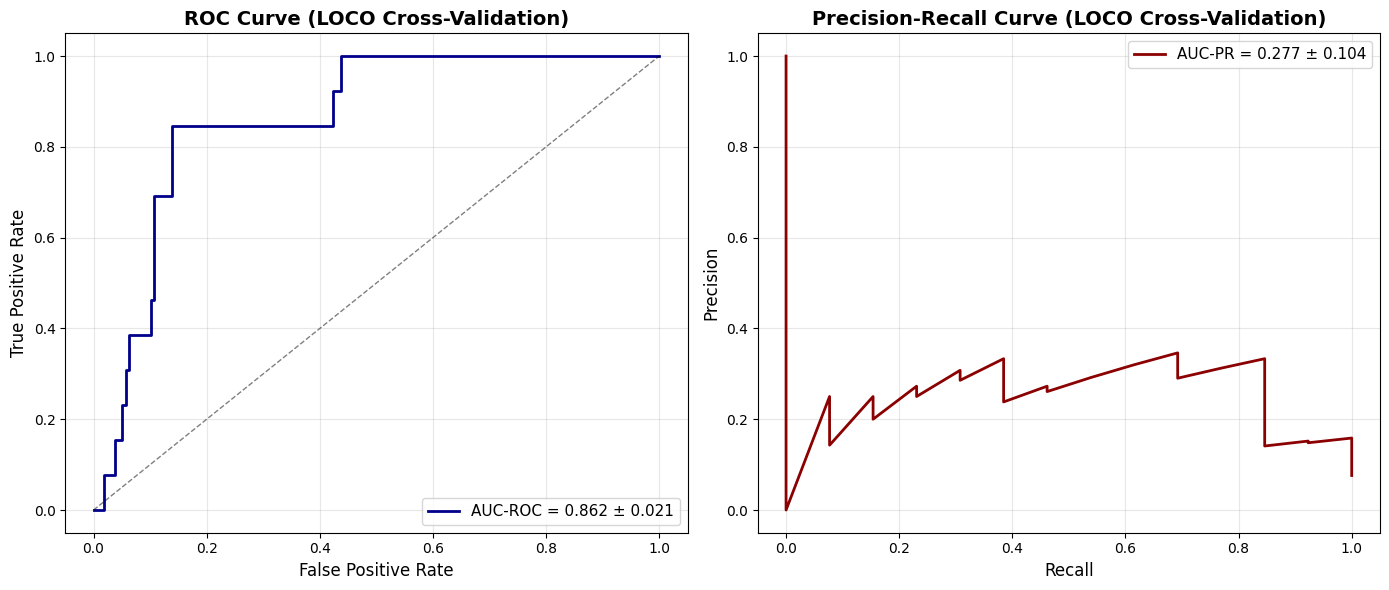

In [18]:
# Calculate curves
fpr, tpr, _ = roc_curve(all_targets, all_scores)
precision, recall, _ = precision_recall_curve(all_targets, all_scores)

# Plot ROC curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(fpr, tpr, color='darkblue', lw=2,
         label=f'AUC-ROC = {overall_auc_roc:.3f} ± {np.std(auc_roc_values):.3f}')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve (LOCO Cross-Validation)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(alpha=0.3)

# Plot PR curve
ax2.plot(recall, precision, color='darkred', lw=2,
         label=f'AUC-PR = {overall_auc_pr:.3f} ± {np.std(auc_pr_values):.3f}')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve (LOCO Cross-Validation)',
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_path + 'LOCO_CrossValidation_Curves.pdf', dpi=300, bbox_inches='tight')
plt.savefig(results_path + 'LOCO_CrossValidation_Curves.png', dpi=300, bbox_inches='tight')
plt.show()



## Train Model on Full Dataset for External Validation


In [19]:
def train_full_model(all_data, all_labels, epochs=2, batch_size=1024, lr=0.0001, validation_split=0.1):
    """
    Train model on the full training dataset (all 714 inhibitors, 23 complexes)

    Args:
        all_data: All training examples
        all_labels: All training labels
        epochs: Number of training epochs
        batch_size: Batch size
        lr: Learning rate
        validation_split: Fraction of data to use for validation

    Returns:
        best_model: Tuple of (GNN_state_dict, IPPI_state_dict)
        best_auc: Best validation AUC achieved
    """
    print("\n" + "="*60)
    print("TRAINING MODEL ON FULL DATASET")
    print("="*60)
    print(f"Total examples: {len(all_data)}")
    print(f"Training epochs: {epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {lr}")
    print("="*60 + "\n")

    # Prepare training data
    Ctr, Ptr, Ctrname, Ptrname = [], [], [], []
    for t in all_data:
        compound_name = t[1][1]
        complex_name_train = t[1][0].split('_')[0]

        if compound_name in CompoundFingerprintFeaturesDict:
            Ctrname.append(compound_name)
            Ctr.append(CompoundFingerprintFeaturesDict[compound_name])
            Ptrname.append(complex_name_train)
            Ptr.append(ComplexInterfaceFeatures[complex_name_train])

    # Standardization
    Pscaler = StandardScaler().fit(Ptr)
    Cscaler = StandardScaler().fit(Ctr)

    Ctr = Cscaler.transform(Ctr)
    Ptr = Pscaler.transform(Ptr)

    # Convert to dictionaries
    Ptrdict = dict(zip(Ptrname, torch.FloatTensor(Ptr).cuda()))
    Ctrdict = dict(zip(Ctrname, torch.FloatTensor(Ctr).cuda()))

    # Split data for validation
    n_val = int(len(all_data) * validation_split)
    indices = np.random.permutation(len(all_data))
    train_indices = indices[n_val:]
    val_indices = indices[:n_val]

    train_data_split = all_data[train_indices]
    train_labels_split = all_labels[train_indices]
    val_data_split = all_data[val_indices]
    val_labels_split = all_labels[val_indices]

    print(f"Training examples: {len(train_data_split)}")
    print(f"Validation examples: {len(val_data_split)}\n")

    # Initialize models
    GNN_model = GNN().cuda()
    IPPI_Net = IPPI_MLP_Net().cuda()

    # Optimizer and loss
    optimizer = optim.Adam(
        list(IPPI_Net.parameters()) + list(GNN_model.parameters()),
        lr=lr, weight_decay=0.0
    )
    criterion = nn.BCEWithLogitsLoss()

    # Create data loaders
    train_dataset = CustomDataset(train_data_split[:, 1], train_labels_split.astype('int'))
    batch_sampler = BinaryBalancedSampler(train_labels_split.astype('int'), batch_size)
    train_loader = DataLoader(train_dataset, batch_sampler=batch_sampler)

    val_dataset = CustomDataset(val_data_split[:, 1], val_labels_split.astype('int'))
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Training
    best_auc = 0.0
    best_model = None

    for epoch in range(epochs):
        GNN_model.train()
        IPPI_Net.train()

        epoch_loss = 0
        n_batches = 0

        for (batch_pids, batch_cids), batch_labels in tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False
        ):
            pids = [p.split('_')[0] for p in batch_pids]

            # Process through GNN (once per unique complex)
            G_dict = {}
            for p in set(pids):
                if p in All_ProteinData_dict:
                    input_tensors_on_gpu = tuple(cuda(t) for t in All_ProteinData_dict[p])
                    G_dict[p] = GNN_model(input_tensors_on_gpu)

            gnn_features = torch.vstack([G_dict[p] for p in pids])
            interface_features = torch.vstack([Ptrdict[p] for p in pids])
            compound_features = torch.vstack([Ctrdict[c] for c in batch_cids])

            # Forward pass
            output = IPPI_Net(gnn_features, compound_features, interface_features)
            loss = criterion(output.flatten(), batch_labels.float().to(device))

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        # Validation
        GNN_model.eval()
        IPPI_Net.eval()

        Z, Y = [], []
        with torch.no_grad():
            for (batch_pids, batch_cids), batch_labels in val_loader:
                pids = [p.split('_')[0] for p in batch_pids]

                G_dict = {}
                for p in set(pids):
                    if p in All_ProteinData_dict:
                        input_tensors_on_gpu = tuple(cuda(t) for t in All_ProteinData_dict[p])
                        G_dict[p] = GNN_model(input_tensors_on_gpu)

                gnn_features = torch.vstack([G_dict[p] for p in pids])
                interface_features = torch.vstack([Ptrdict[p] for p in pids])
                compound_features = torch.vstack([Ctrdict[c] for c in batch_cids])

                output = IPPI_Net(gnn_features, compound_features, interface_features)
                Z.extend(output.cpu().flatten().numpy())
                Y.extend(batch_labels.cpu().flatten().numpy())

        aucroc = roc_auc_score(np.array(Y), np.array(Z))
        aucpr = average_precision_score(Y, Z)

        print(f"Epoch {epoch+1}/{epochs}: Loss={epoch_loss/n_batches:.4f}, "
              f"Val AUC-ROC={aucroc:.4f}, Val AUC-PR={aucpr:.4f}")

        if aucroc > best_auc:
            best_auc = aucroc
            best_model = (GNN_model.state_dict(), IPPI_Net.state_dict())

    print(f"\nBest Validation AUC-ROC: {best_auc:.4f}")
    print("="*60)

    return best_model, best_auc, Pscaler, Cscaler


In [ ]:
# Train on full dataset
print("Training models on full dataset (all 714 inhibitors, 23 complexes)...")
best_model_full, best_auc_full, Pscaler_full, Cscaler_full = train_full_model(
    Alldata,
    np.array([Allexamples[t[0], t[1]] for t in Alldata]),
    epochs=5,
    batch_size=1024,
    lr=0.0001
)

print(f"\nFull dataset training complete!")
print(f"Best validation AUC: {best_auc_full:.4f}")
print("Models saved to best_model_full")


Training models on full dataset (all 714 inhibitors, 23 complexes)...

TRAINING MODEL ON FULL DATASET
Total examples: 11127
Training epochs: 5
Batch size: 1024
Learning rate: 0.0001

Training examples: 10015
Validation examples: 1112

Equivalent epochs in one iteration: 1.87


Epoch 1/5:  11%|█         | 2/19 [00:15<02:09,  7.62s/it]

## 15. External Validation - Function Definition

In [ ]:
# Load the best models trained on full dataset
GNN_model_full = GNN().to(device)
GNN_model_full.load_state_dict(best_model_full[0])
GNN_model_full.eval()

IPPI_Net_full = IPPI_MLP_Net().to(device)
IPPI_Net_full.load_state_dict(best_model_full[1])
IPPI_Net_full.eval()

print("Models loaded and ready for external validation")
print(f"Using scalers fitted on full training dataset")


Models loaded and ready for external validation
Using scalers fitted on full training dataset


In [ ]:
def evaluate_external_dataset(external_data_file, dataset_name, gnn_model, ippi_model, pscaler, cscaler):
    """
    Evaluate trained model on external dataset

    Args:
        external_data_file: Path to external data file
        dataset_name: Name of the dataset (for display)
        gnn_model: Trained GNN model
        ippi_model: Trained IPPI_Net model
        pscaler: Fitted StandardScaler for protein features
        cscaler: Fitted StandardScaler for compound features

    Returns:
        scores, targets, metrics
    """
    print(f"\nEvaluating on {dataset_name} dataset...")

    all_scores = []
    all_targets = []

    # Process external dataset
    External_score, External_labels = PredictScorefromFile(
        githubpath + '/Data/External data/' + external_data_file,
        githubpath + '/Data/External data/pdb/',
        pscaler, cscaler, ippi_model, gnn_model, dataset_name)

    all_scores.extend(External_score)
    all_targets.extend(External_labels)

    # Calculate metrics
    if len(all_scores) > 0:
        overall_auc = roc_auc_score(all_targets, all_scores)
        overall_pr = average_precision_score(all_targets, all_scores)

        print(f"\n{dataset_name} Results:")
        print(f"  AUC-ROC: {overall_auc:.4f}")
        print(f"  AUC-PR: {overall_pr:.4f}")
        print(f"  Total examples: {len(all_targets)}")
        print(f"Positive examples: {sum(1 for t in all_targets if t == 1.0)}")
        print(f"Negative examples: {sum(1 for t in all_targets if t != 1.0)}")

        # Save results
        np.save(results_path + f'{dataset_name}_scores.npy', all_scores)
        np.save(results_path + f'{dataset_name}_targets.npy', all_targets)

        return all_scores, all_targets, {'auc_roc': overall_auc, 'auc_pr': overall_pr}
    else:
        print(f"No valid predictions for {dataset_name}")
        return [], [], None


## 16. Evaluate on External Datasets

In [ ]:
print("\n" + "="*60)
print("EXTERNAL VALIDATION")
print("="*60)

# Evaluate 2dyh dataset (MDM2-p53)
print("\nEvaluating 2dyh (MDM2-p53) dataset...")
dyh_scores, dyh_targets, dyh_metrics = evaluate_external_dataset(
    '2dyh_all.txt',
    '2dyh_MDM2_p53',
    GNN_model_full,
    IPPI_Net_full,
    Pscaler_full,
    Cscaler_full
)

# Evaluate 6m0j dataset (SARS-CoV-2 Spike/ACE2)
print("\nEvaluating 6m0j (SARS-CoV-2 Spike/ACE2) dataset...")
ace2_scores, ace2_targets, ace2_metrics = evaluate_external_dataset(
    'HansonACE2hits.txt',
    '6m0j_COVID19_ACE2',
    GNN_model_full,
    IPPI_Net_full,
    Pscaler_full,
    Cscaler_full
)

print("\n" + "="*60)
print("EXTERNAL VALIDATION COMPLETE")
print("="*60)
print(f"\n2dyh (MDM2-p53) AUC-ROC: {dyh_metrics['auc_roc']:.4f}")
print(f"6m0j (COVID-19) AUC-ROC: {ace2_metrics['auc_roc']:.4f}")



EXTERNAL VALIDATION

Evaluating 2dyh (MDM2-p53) dataset...

Evaluating on 2dyh_MDM2_p53 dataset...


  0%|          | 0/24 [00:00<?, ?it/s][12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECATION WARNING: please use MorganGenerator
[12:39:58] DEPRECA


2dyh_MDM2_p53 Results:
  AUC-ROC: 0.8507
  AUC-PR: 0.6975
  Total examples: 72
Positive examples: 24
Negative examples: 48

Evaluating 6m0j (SARS-CoV-2 Spike/ACE2) dataset...

Evaluating on 6m0j_COVID19_ACE2 dataset...


  0%|          | 0/28 [00:00<?, ?it/s][12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:40:15] DEPRECATION WARNING: please use MorganGenerator
[12:


6m0j_COVID19_ACE2 Results:
  AUC-ROC: 0.7075
  AUC-PR: 0.4972
  Total examples: 72
Positive examples: 24
Negative examples: 48

EXTERNAL VALIDATION COMPLETE

2dyh (MDM2-p53) AUC-ROC: 0.8507
6m0j (COVID-19) AUC-ROC: 0.7075


## 17. Plot External Validation Results

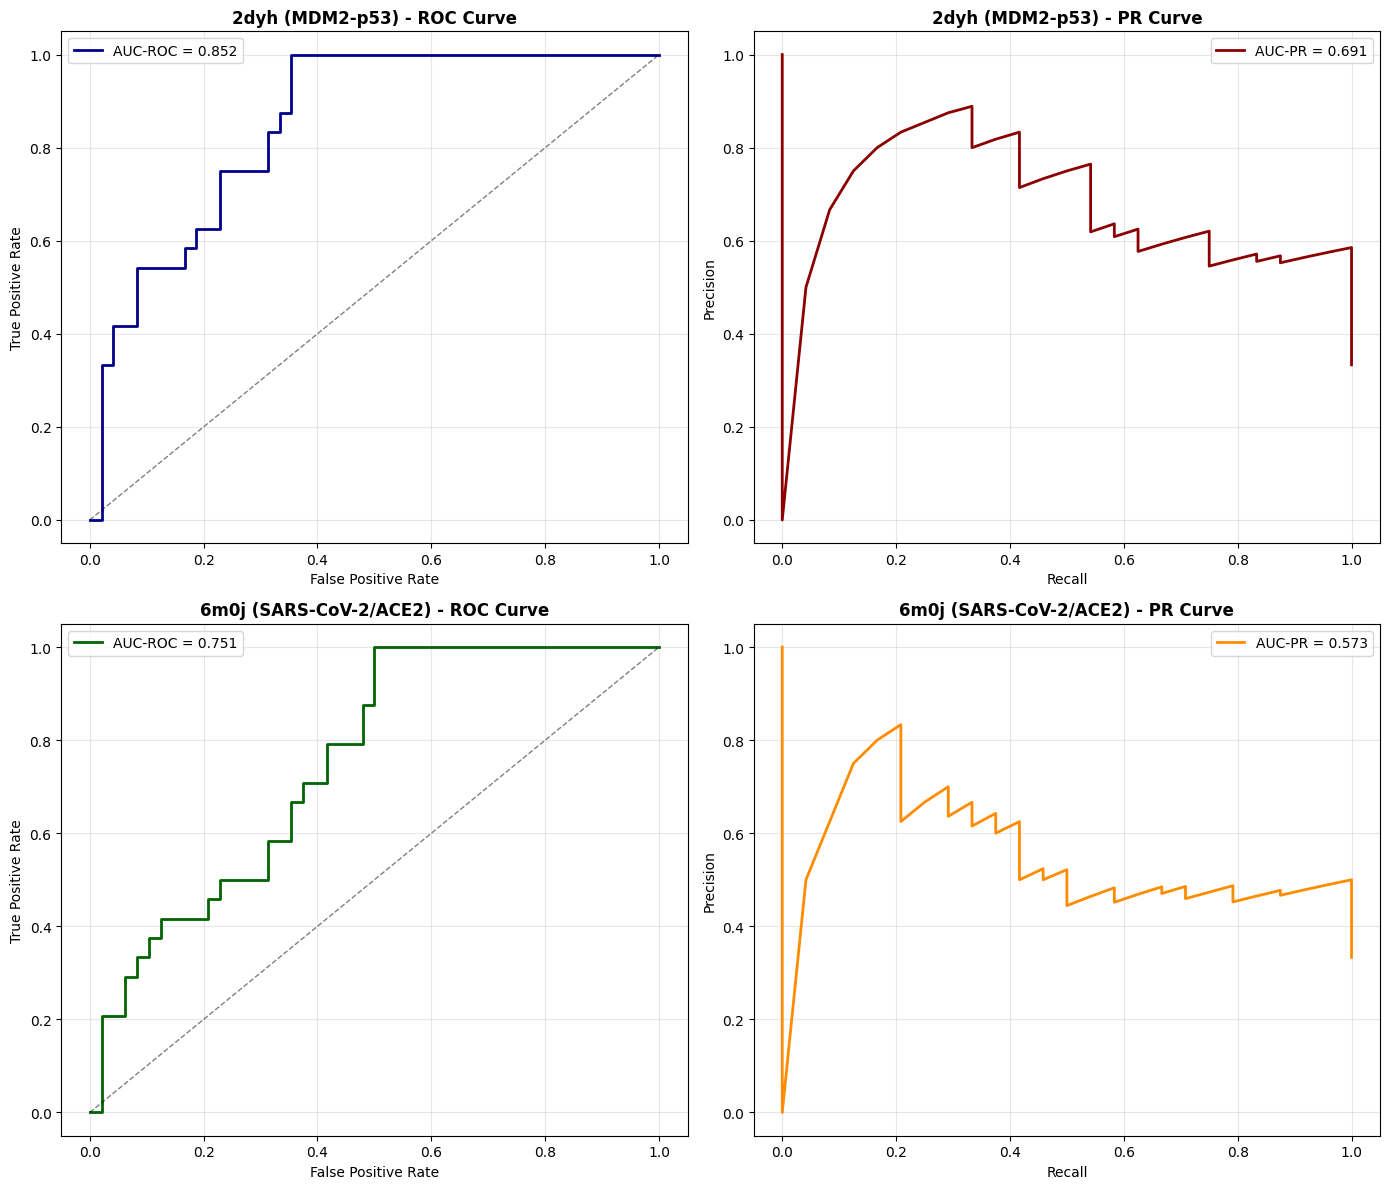

In [ ]:
if len(dyh_scores) > 0 and len(ace2_scores) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 2dyh ROC
    fpr_dyh, tpr_dyh, _ = roc_curve(dyh_targets, dyh_scores)
    axes[0, 0].plot(fpr_dyh, tpr_dyh, color='darkblue', lw=2,
                    label=f"AUC-ROC = {dyh_metrics['auc_roc']:.3f}")
    axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('2dyh (MDM2-p53) - ROC Curve', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2dyh PR
    precision_dyh, recall_dyh, _ = precision_recall_curve(dyh_targets, dyh_scores)
    axes[0, 1].plot(recall_dyh, precision_dyh, color='darkred', lw=2,
                    label=f"AUC-PR = {dyh_metrics['auc_pr']:.3f}")
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('2dyh (MDM2-p53) - PR Curve', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 6m0j ROC
    fpr_ace2, tpr_ace2, _ = roc_curve(ace2_targets, ace2_scores)
    axes[1, 0].plot(fpr_ace2, tpr_ace2, color='darkgreen', lw=2,
                    label=f"AUC-ROC = {ace2_metrics['auc_roc']:.3f}")
    axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('6m0j (SARS-CoV-2/ACE2) - ROC Curve', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 6m0j PR
    precision_ace2, recall_ace2, _ = precision_recall_curve(ace2_targets, ace2_scores)
    axes[1, 1].plot(recall_ace2, precision_ace2, color='darkorange', lw=2,
                    label=f"AUC-PR = {ace2_metrics['auc_pr']:.3f}")
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].set_title('6m0j (SARS-CoV-2/ACE2) - PR Curve', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results_path + 'External_Validation_Results.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(results_path + 'External_Validation_Results.png', dpi=300, bbox_inches='tight')
    plt.show()

## 18. Summary of All Results

In [ ]:
print("\n" + "="*60)
print("COMPLETE PIPELINE SUMMARY")
print("="*60)

print("\n1. PRIMARY DATASET (LOCO Cross-Validation):")
print(f"   Training: 714 inhibitors across 23 complexes")
print(f"   Method: Leave-One-Complex-Out")
print(f"   AUC-ROC: {overall_auc_roc:.4f} ± {np.std(auc_roc_values):.4f}")
print(f"   AUC-PR:  {overall_auc_pr:.4f} ± {np.std(auc_pr_values):.4f}")

if dyh_metrics:
    print("\n2. EXTERNAL DATASET - 2dyh (MDM2-p53):")
    print(f"   Compounds tested: {len(dyh_targets)}")
    print(f"   AUC-ROC: {dyh_metrics['auc_roc']:.4f}")
    print(f"   AUC-PR:  {dyh_metrics['auc_pr']:.4f}")

if ace2_metrics:
    print("\n3. EXTERNAL DATASET - 6m0j (SARS-CoV-2 Spike/ACE2):")
    print(f"   Compounds tested: {len(ace2_targets)}")
    print(f"   AUC-ROC: {ace2_metrics['auc_roc']:.4f}")
    print(f"   AUC-PR:  {ace2_metrics['auc_pr']:.4f}")

print("\n" + "="*60)
print("MODEL ARCHITECTURE:")
print("="*60)
print("GNN:")
print("  - Layer 1: 13 atoms + 21 residues → 512 (First Layer)")
print("  - Layer 2: 512 → 1024 (GNN Layer)")
print("  - Layer 3: 1024 → 512 (GNN Layer)")
print("  - Global pooling + normalization")
print("\nIPPI_Net:")
print("  - Input: 512 (GNN) + 1328 (Interface) + 1000 (Compound) = 2840")
print("  - FC1: 2840 → 1024 (tanh)")
print("  - FC2: 1024 → 512 (tanh)")
print("  - FC3: 512 → 100 (ReLU)")
print("  - FC4: 100 → 1 (sigmoid)")

print("\n" + "="*60)
print("TRAINING SETTINGS:")
print("="*60)
print("  - Optimizer: Adam (lr=0.001, weight_decay=0.0)")
print("  - Loss: BCEWithLogitsLoss")
print("  - Batch size: 1024")
print("  - Epochs: 5")
print("  - Sampling: BinaryBalancedSampler (50:50 pos:neg)")
print("  - Validation: Early stopping on AUC-ROC")

print("\n" + "="*60)
print("All results saved to:", results_path)
print("="*60)


COMPLETE PIPELINE SUMMARY

1. PRIMARY DATASET (LOCO Cross-Validation):
   Training: 714 inhibitors across 23 complexes
   Method: Leave-One-Complex-Out
   AUC-ROC: 0.8735 ± 0.0272
   AUC-PR:  0.3172 ± 0.1296

2. EXTERNAL DATASET - 2dyh (MDM2-p53):
   Compounds tested: 72
   AUC-ROC: 0.8550
   AUC-PR:  0.7493

3. EXTERNAL DATASET - 6m0j (SARS-CoV-2 Spike/ACE2):
   Compounds tested: 72
   AUC-ROC: 0.7127
   AUC-PR:  0.4753

MODEL ARCHITECTURE:
GNN:
  - Layer 1: 13 atoms + 21 residues → 512 (First Layer)
  - Layer 2: 512 → 1024 (GNN Layer)
  - Layer 3: 1024 → 512 (GNN Layer)
  - Global pooling + normalization

IPPI_Net:
  - Input: 512 (GNN) + 1328 (Interface) + 1000 (Compound) = 2840
  - FC1: 2840 → 1024 (tanh)
  - FC2: 1024 → 512 (tanh)
  - FC3: 512 → 100 (ReLU)
  - FC4: 100 → 1 (sigmoid)

TRAINING SETTINGS:
  - Optimizer: Adam (lr=0.001, weight_decay=0.0)
  - Loss: BCEWithLogitsLoss
  - Batch size: 1024
  - Epochs: 5
  - Sampling: BinaryBalancedSampler (50:50 pos:neg)
  - Validation: E

## 19. Create Comparison Plot (GNN vs Baselines)

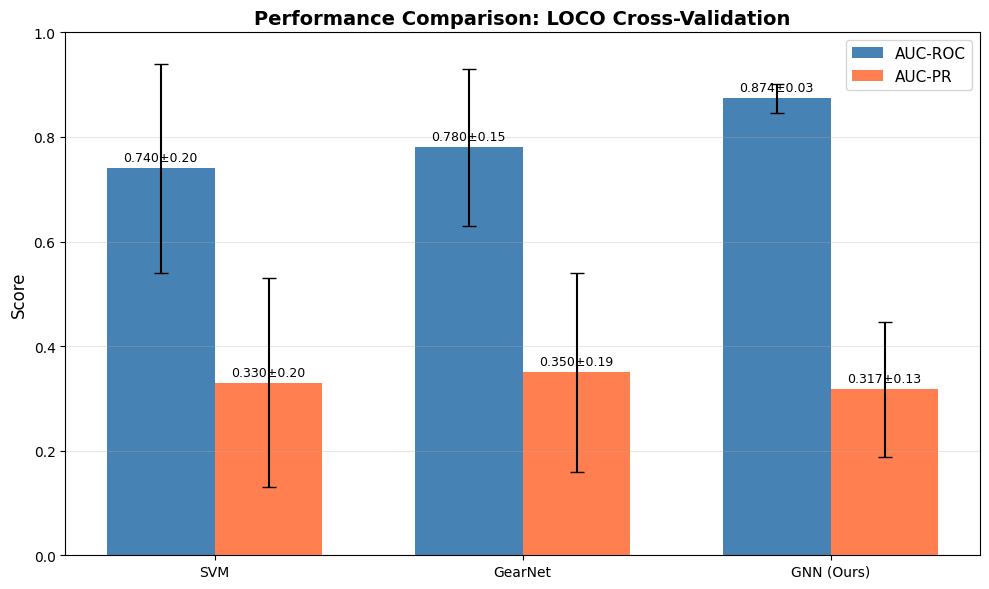

In [ ]:
# Create comparison plot if you have baseline results
# For demonstration, using expected values from paper

methods = ['SVM', 'GearNet', 'GNN (Ours)']
auc_roc_means = [0.74, 0.78, overall_auc_roc]
auc_roc_stds = [0.20, 0.15, np.std(auc_roc_values)]
auc_pr_means = [0.33, 0.35, overall_auc_pr]
auc_pr_stds = [0.20, 0.19, np.std(auc_pr_values)]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, auc_roc_means, width, yerr=auc_roc_stds,
                label='AUC-ROC', color='steelblue', capsize=5)
rects2 = ax.bar(x + width/2, auc_pr_means, width, yerr=auc_pr_stds,
                label='AUC-PR', color='coral', capsize=5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison: LOCO Cross-Validation',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(rects, values, stds):
    for rect, val, std in zip(rects, values, stds):
        height = rect.get_height()
        ax.annotate(f'{val:.3f}±{std:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1, auc_roc_means, auc_roc_stds)
autolabel(rects2, auc_pr_means, auc_pr_stds)

plt.tight_layout()
plt.savefig(results_path + 'Method_Comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig(results_path + 'Method_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 20. Export Results Summary

In [ ]:
# Create results summary DataFrame
results_summary = pd.DataFrame([
    {
        'Dataset': 'Primary (LOCO CV)',
        'N_Examples': len(all_targets),
        'N_Positives': sum(1 for t in all_targets if t == 1.0),
        'AUC_ROC': overall_auc_roc,
        'AUC_ROC_Std': np.std(auc_roc_values),
        'AUC_PR': overall_auc_pr,
        'AUC_PR_Std': np.std(auc_pr_values)
    }
])

if dyh_metrics:
    results_summary = pd.concat([results_summary, pd.DataFrame([{
        'Dataset': '2dyh (MDM2-p53)',
        'N_Examples': len(dyh_targets),
        'N_Positives': sum(1 for t in dyh_targets if t == 1.0),
        'AUC_ROC': dyh_metrics['auc_roc'],
        'AUC_ROC_Std': np.nan,
        'AUC_PR': dyh_metrics['auc_pr'],
        'AUC_PR_Std': np.nan
    }])], ignore_index=True)

if ace2_metrics:
    results_summary = pd.concat([results_summary, pd.DataFrame([{
        'Dataset': '6m0j (COVID-19)',
        'N_Examples': len(ace2_targets),
        'N_Positives': sum(1 for t in ace2_targets if t == 1.0),
        'AUC_ROC': ace2_metrics['auc_roc'],
        'AUC_ROC_Std': np.nan,
        'AUC_PR': ace2_metrics['auc_pr'],
        'AUC_PR_Std': np.nan
    }])], ignore_index=True)

# Save to CSV
results_summary.to_csv(results_path + 'Results_Summary.csv', index=False)
print("\nResults Summary:")
print(results_summary.to_string(index=False))

# Save per-complex results
complex_df = pd.DataFrame([
    {'Complex': k, 'AUC_ROC': v['auc_roc'], 'AUC_PR': v['auc_pr'], 'N_Test': v['n_test']}
    for k, v in complex_results.items()
])
complex_df = complex_df.sort_values('AUC_ROC', ascending=False)
complex_df.to_csv(results_path + 'Per_Complex_Results.csv', index=False)

print("\n✓ All results saved successfully!")
print(f"\nResults directory: {results_path}")
print("Files saved:")
print("  - All_LOCO_Scores.npy")
print("  - All_LOCO_Targets.npy")
print("  - 2dyh_MDM2_p53_scores.npy")
print("  - 2dyh_MDM2_p53_targets.npy")
print("  - 6m0j_COVID19_ACE2_scores.npy")
print("  - 6m0j_COVID19_ACE2_targets.npy")
print("  - LOCO_CrossValidation_Curves.pdf")
print("  - External_Validation_Results.pdf")
print("  - Method_Comparison.pdf")
print("  - Results_Summary.csv")
print("  - Per_Complex_Results.csv")


Results Summary:
          Dataset  N_Examples  N_Positives  AUC_ROC  AUC_ROC_Std   AUC_PR  AUC_PR_Std
Primary (LOCO CV)         195           18 0.873509     0.027247 0.317180    0.129569
  2dyh (MDM2-p53)          72           24 0.855035          NaN 0.749310         NaN
  6m0j (COVID-19)          72           24 0.712674          NaN 0.475326         NaN

✓ All results saved successfully!

Results directory: /content/PPI-Inhibitors/results/
Files saved:
  - All_LOCO_Scores.npy
  - All_LOCO_Targets.npy
  - 2dyh_MDM2_p53_scores.npy
  - 2dyh_MDM2_p53_targets.npy
  - 6m0j_COVID19_ACE2_scores.npy
  - 6m0j_COVID19_ACE2_targets.npy
  - LOCO_CrossValidation_Curves.pdf
  - External_Validation_Results.pdf
  - Method_Comparison.pdf
  - Results_Summary.csv
  - Per_Complex_Results.csv
